# Предобработка рисунков


## Лёгкий случай: чистый контур на белом фоне
Рисунок с чёткими линиями, возможно рамка/артефакты по краям

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


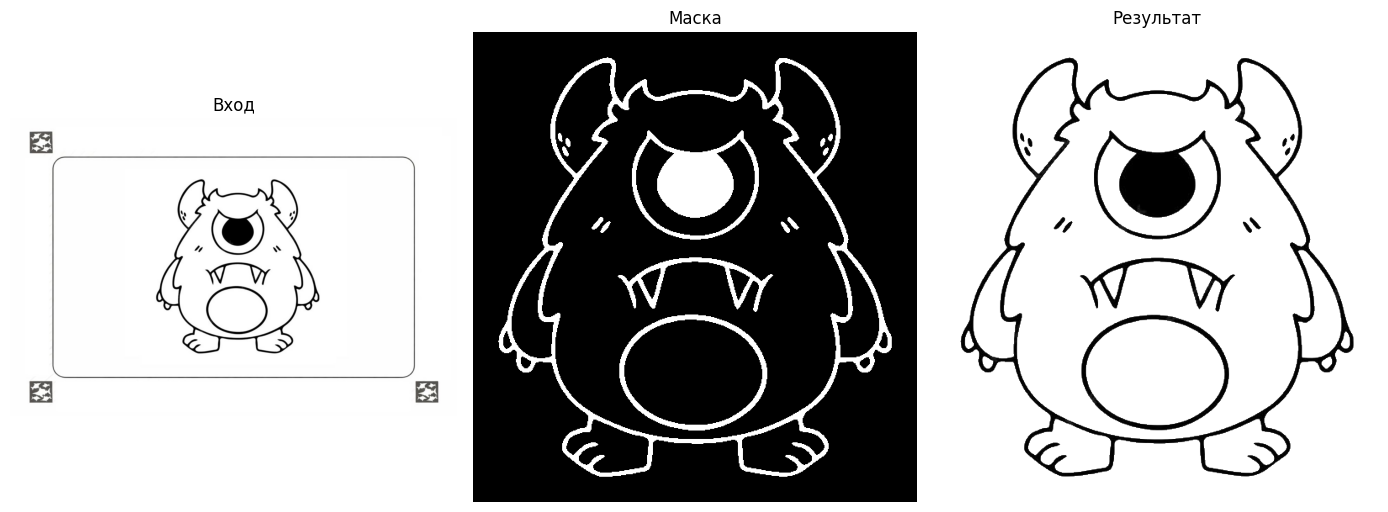

Сохранено: OUTPUT/img02_clean.png


In [7]:
%load_ext autoreload
%autoreload 2

import cv2
import numpy as np
from pathlib import Path
import matplotlib.pyplot as plt

def preprocess_clean(img_path, output_dir="OUTPUT", pad=30):
    """Извлекает персонажа из рисунка на белом фоне."""
    img = cv2.imread(str(img_path))
    gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
    h, w = gray.shape
    
    # Бинаризация (Otsu)
    _, binary = cv2.threshold(gray, 0, 255, cv2.THRESH_BINARY_INV + cv2.THRESH_OTSU)
    binary = cv2.morphologyEx(binary, cv2.MORPH_OPEN, 
                               cv2.getStructuringElement(cv2.MORPH_ELLIPSE, (3, 3)))
    
    # Убираем всё что касается краёв (рамки, маркеры)
    clean = binary.copy()
    flood_mask = np.zeros((h + 2, w + 2), dtype=np.uint8)
    for x in range(w):
        if clean[0, x] > 0:
            cv2.floodFill(clean, flood_mask, (x, 0), 0)
        if clean[h-1, x] > 0:
            cv2.floodFill(clean, flood_mask, (x, h-1), 0)
    for y in range(h):
        if clean[y, 0] > 0:
            cv2.floodFill(clean, flood_mask, (0, y), 0)
        if clean[y, w-1] > 0:
            cv2.floodFill(clean, flood_mask, (w-1, y), 0)
    
    # Соединяем близкие части + берём главный blob
    connected = cv2.dilate(clean, cv2.getStructuringElement(cv2.MORPH_ELLIPSE, (25, 25)))
    contours, _ = cv2.findContours(connected, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)
    biggest = max(contours, key=cv2.contourArea)
    
    blob_mask = np.zeros((h, w), dtype=np.uint8)
    cv2.drawContours(blob_mask, [biggest], -1, 255, cv2.FILLED)
    mask = binary & blob_mask
    
    # Кроп
    x, y, cw, ch = cv2.boundingRect(cv2.findNonZero(mask))
    x1, y1 = max(0, x - pad), max(0, y - pad)
    x2, y2 = min(w, x + cw + pad), min(h, y + ch + pad)
    
    crop = img[y1:y2, x1:x2]
    crop_mask = mask[y1:y2, x1:x2]
    
    # RGBA
    b, g, r = cv2.split(crop)
    rgba = cv2.merge([b, g, r, crop_mask])
    
    Path(output_dir).mkdir(exist_ok=True)
    out_path = f"{output_dir}/{Path(img_path).stem}_clean.png"
    cv2.imwrite(out_path, rgba)
    
    return {'crop': crop, 'crop_mask': crop_mask, 'rgba': rgba, 'path': out_path}

# Запуск
result = preprocess_clean("INPUT/img02.jpg")

fig, axes = plt.subplots(1, 3, figsize=(14, 5))
axes[0].imshow(cv2.cvtColor(cv2.imread("INPUT/img02.jpg"), cv2.COLOR_BGR2RGB))
axes[0].set_title('Вход')
axes[1].imshow(result['crop_mask'], cmap='gray')
axes[1].set_title('Маска')
axes[2].imshow(cv2.cvtColor(result['rgba'], cv2.COLOR_BGRA2RGBA))
axes[2].set_title('Результат')
for ax in axes:
    ax.axis('off')
plt.tight_layout()
plt.show()
print(f"Сохранено: {result['path']}")

## Случай 2: Цветной рисунок на белом фоне
Убираем белый фон, сохраняем цвета.


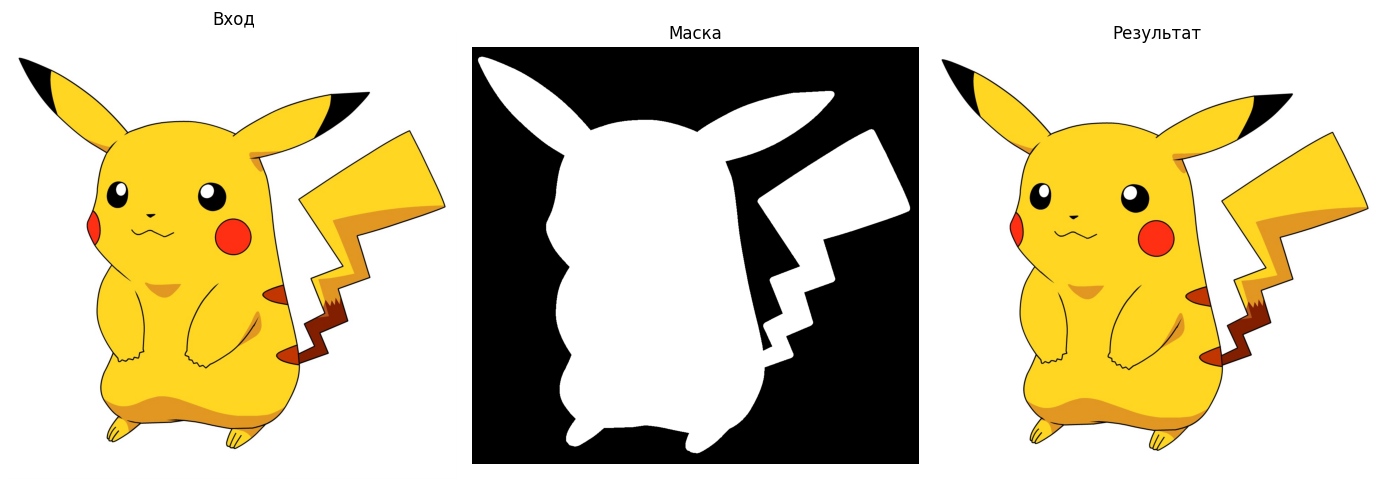

In [7]:
def preprocess_color(img_path, output_dir="OUTPUT", pad=30, white_thresh=240):
    """Извлекает цветного персонажа: убираем белый фон, сохраняем цвета."""
    img = cv2.imread(str(img_path))
    h, w = img.shape[:2]
    
    # Белый фон = все каналы > порога
    gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
    _, bg_mask = cv2.threshold(gray, white_thresh, 255, cv2.THRESH_BINARY)
    fg_mask = cv2.bitwise_not(bg_mask)
    
    # Чистим мелкий шум
    kernel = cv2.getStructuringElement(cv2.MORPH_ELLIPSE, (3, 3))
    fg_mask = cv2.morphologyEx(fg_mask, cv2.MORPH_OPEN, kernel)
    
    # Убираем артефакты с краёв
    clean = fg_mask.copy()
    flood_mask = np.zeros((h + 2, w + 2), dtype=np.uint8)
    for x in range(w):
        if clean[0, x] > 0:
            cv2.floodFill(clean, flood_mask, (x, 0), 0)
        if clean[h-1, x] > 0:
            cv2.floodFill(clean, flood_mask, (x, h-1), 0)
    for y in range(h):
        if clean[y, 0] > 0:
            cv2.floodFill(clean, flood_mask, (0, y), 0)
        if clean[y, w-1] > 0:
            cv2.floodFill(clean, flood_mask, (w-1, y), 0)
    
    # Соединяем + берём главный blob
    connected = cv2.dilate(clean, cv2.getStructuringElement(cv2.MORPH_ELLIPSE, (15, 15)))
    contours, _ = cv2.findContours(connected, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)
    if not contours:
        return None
    biggest = max(contours, key=cv2.contourArea)
    
    blob_mask = np.zeros((h, w), dtype=np.uint8)
    cv2.drawContours(blob_mask, [biggest], -1, 255, cv2.FILLED)
    
    # Финальная маска: blob целиком (заливка внутри контура)
    mask = blob_mask
    
    # Кроп
    x, y, cw, ch = cv2.boundingRect(cv2.findNonZero(mask))
    x1, y1 = max(0, x - pad), max(0, y - pad)
    x2, y2 = min(w, x + cw + pad), min(h, y + ch + pad)
    
    crop = img[y1:y2, x1:x2]
    crop_mask = mask[y1:y2, x1:x2]
    
    # RGBA — сохраняем цвета
    b, g, r = cv2.split(crop)
    rgba = cv2.merge([b, g, r, crop_mask])
    
    Path(output_dir).mkdir(exist_ok=True)
    out_path = f"{output_dir}/{Path(img_path).stem}_clean.png"
    cv2.imwrite(out_path, rgba)
    
    return {'crop': crop, 'crop_mask': crop_mask, 'rgba': rgba, 'path': out_path}

# Запуск
result = preprocess_color("INPUT/img03.jpg")

fig, axes = plt.subplots(1, 3, figsize=(14, 5))
axes[0].imshow(cv2.cvtColor(cv2.imread("INPUT/img03.jpg"), cv2.COLOR_BGR2RGB))
axes[0].set_title('Вход')
axes[1].imshow(result['crop_mask'], cmap='gray')
axes[1].set_title('Маска')
axes[2].imshow(cv2.cvtColor(result['rgba'], cv2.COLOR_BGRA2RGBA))
axes[2].set_title('Результат')
for ax in axes:
    ax.axis('off')
plt.tight_layout()
plt.show()

## Случай 3: Фото рисунка на реальном фоне
Крафт-бумага, тени, стиль ресунка — CV не справится, используем AI (rembg)

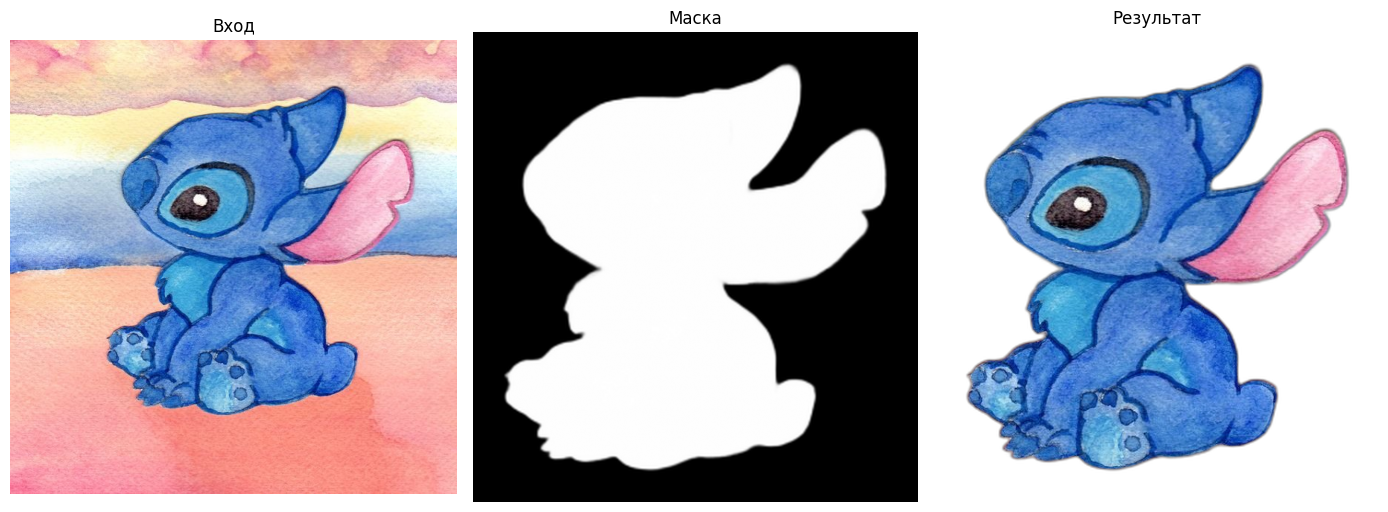

Сохранено: OUTPUT/img04_clean.png


In [6]:
import cv2
import numpy as np
from pathlib import Path
from PIL import Image
from rembg import remove
import matplotlib.pyplot as plt

def preprocess_complex(img_path, output_dir="OUTPUT", pad=30):
    """Извлекает персонажа с фото на сложном фоне через AI."""
    inp = Image.open(str(img_path))
    result = remove(inp)
    
    rgba = np.array(result)
    mask = rgba[:, :, 3]
    
    coords = cv2.findNonZero(mask)
    if coords is None:
        return None
    x, y, w, h = cv2.boundingRect(coords)
    H, W = mask.shape
    x1, y1 = max(0, x - pad), max(0, y - pad)
    x2, y2 = min(W, x + w + pad), min(H, y + h + pad)
    
    crop_rgba = rgba[y1:y2, x1:x2]
    crop_mask = mask[y1:y2, x1:x2]
    
    Path(output_dir).mkdir(exist_ok=True)
    out_path = f"{output_dir}/{Path(img_path).stem}_clean.png"
    Image.fromarray(crop_rgba).save(out_path)
    
    return {'crop_rgba': crop_rgba, 'crop_mask': crop_mask, 'path': out_path}

result = preprocess_complex("INPUT/img04.jpg")

fig, axes = plt.subplots(1, 3, figsize=(14, 5))
axes[0].imshow(Image.open("INPUT/img04.jpg"))
axes[0].set_title('Вход')
axes[1].imshow(result['crop_mask'], cmap='gray')
axes[1].set_title('Маска')
axes[2].imshow(result['crop_rgba'])
axes[2].set_title('Результат')
for ax in axes:
    ax.axis('off')
plt.tight_layout()
plt.show()
print(f"Сохранено: {result['path']}")

## 1.5 Улучшение: апскейл x4 (Real-ESRGAN)

Каналов на входе: 4
Готово: (511, 483) → (2044, 1932), каналов на выходе: 4


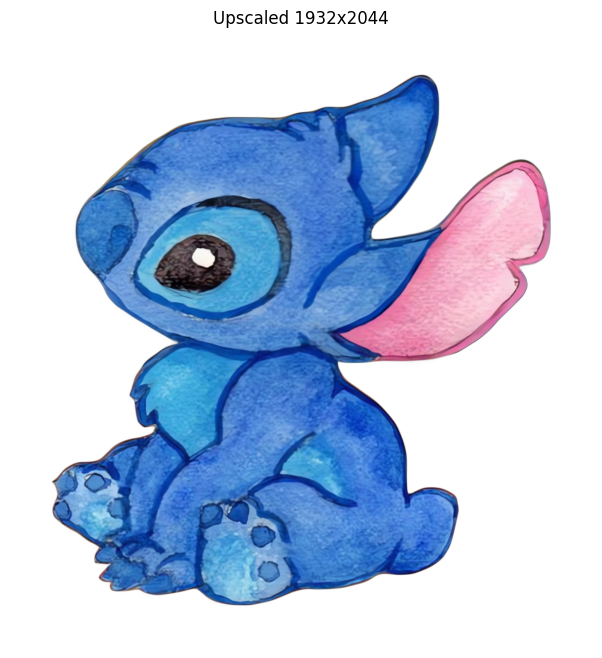

In [12]:
from realesrgan_ncnn_py import Realesrgan

realesrgan = Realesrgan(gpuid=0, model=2)  # model=2 = anime

# Читаем с альфой
img = cv2.imread("OUTPUT/img04_clean.png", cv2.IMREAD_UNCHANGED)
print("Каналов на входе:", img.shape[2])

# Разделяем RGB и Alpha
bgr = img[:, :, :3]
alpha = img[:, :, 3]

# Апскейлим RGB
bgr_up = realesrgan.process_cv2(bgr)

# Апскейлим альфу как grayscale→BGR→обратно
alpha_bgr = cv2.cvtColor(alpha, cv2.COLOR_GRAY2BGR)
alpha_up_bgr = realesrgan.process_cv2(alpha_bgr)
alpha_up = cv2.cvtColor(alpha_up_bgr, cv2.COLOR_BGR2GRAY)

# Склеиваем обратно BGRA
b, g, r = cv2.split(bgr_up)
rgba_up = cv2.merge([b, g, r, alpha_up])

cv2.imwrite("OUTPUT/img04_upscaled.png", rgba_up)
print(f"Готово: {bgr.shape[:2]} → {bgr_up.shape[:2]}, каналов на выходе: {rgba_up.shape[2]}")

plt.figure(figsize=(8, 8))
plt.imshow(cv2.cvtColor(rgba_up, cv2.COLOR_BGRA2RGBA))
plt.axis("off")
plt.title(f"Upscaled {rgba_up.shape[1]}x{rgba_up.shape[0]}")
plt.show()